# Détection automatique de faux billets

## Contexte

L’Organisation nationale de lutte contre le faux-monnayage souhaite développer un outil capable d’identifier automatiquement les faux billets à partir de leurs caractéristiques géométriques.

Le jeu de données mis à disposition contient 1 500 billets, dont 1 000 billets authentiques et 500 faux billets. Chaque billet est décrit par six mesures géométriques.

## Objectifs

Cette étude vise à :

- explorer et préparer les données ;
- comparer plusieurs méthodes d’apprentissage supervisé et non supervisé ;
- évaluer leurs performances ;
- sélectionner le modèle le plus adapté à la détection des faux billets ;
- déployer le modèle final dans un script utilisable sur de nouvelles données.

## 1. Importation des bibliothèques et chargement des données

Cette première étape consiste à préparer l’environnement de travail en important les bibliothèques nécessaires à la manipulation, à la visualisation, au prétraitement et à la modélisation des données.

Les outils utilisés permettront notamment de :

- réaliser l’analyse exploratoire du jeu de données ;
- traiter les éventuelles valeurs manquantes ;
- entraîner et comparer plusieurs modèles d’apprentissage supervisé ainsi qu’un modèle non supervisé ;
- optimiser certains hyperparamètres ;
- évaluer les performances des modèles ;
- sauvegarder le modèle final afin de l’utiliser dans un script de prédiction.

Les quatre approches demandées dans le cahier des charges sont étudiées : la régression logistique, le KNN, le Random Forest et le K-means. Un modèle SVM est également testé à titre exploratoire afin d’élargir la comparaison.

Le fichier `billets.csv` sera ensuite chargé dans un DataFrame pandas. Une première vérification permettra de contrôler l’existence du fichier, ses dimensions et le bon déroulement de l’importation.

In [1]:
# Manipulation des données
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Séparation des données et optimisation des modèles
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate)

# Prétraitement
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modèles supervisés
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Modèle non supervisé
from sklearn.cluster import KMeans

# Évaluation des modèles
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    silhouette_score,
    adjusted_rand_score,
    make_scorer)

# Interprétation des modèles
from sklearn.inspection import permutation_importance

# Sauvegarde et chargement du modèle final
from joblib import dump, load


# Paramètre utilisé pour garantir la reproductibilité des résultats
RANDOM_STATE = 42

In [2]:
# Définition du chemin vers le fichier de données
DATA_PATH = Path("billets.csv")

# Vérification de l'existence du fichier
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Le fichier '{DATA_PATH}' est introuvable.\n"
        f"Dossier de travail actuel : {Path.cwd()}")

# Chargement des données
df = pd.read_csv(DATA_PATH, sep=";")

print("Données chargées avec succès.")
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

display(df.head())

Données chargées avec succès.
Nombre de lignes : 1500
Nombre de colonnes : 7


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


## 2. Analyse exploratoire des données

L’analyse exploratoire vise à comprendre la structure du jeu de données, à contrôler sa qualité et à identifier les éventuels traitements nécessaires avant la modélisation.

Dans un premier temps, nous examinerons les types de variables, les valeurs manquantes et les éventuels doublons.

In [3]:
# Informations générales sur le jeu de données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


### Première observation de la structure des données

Le jeu de données contient 1 500 observations et 7 variables.

La variable cible `is_genuine` est de type booléen, tandis que les six caractéristiques géométriques sont des variables quantitatives continues.

La colonne `margin_low` comporte 37 valeurs manquantes. Toutes les autres variables sont complètes. Un traitement de ces valeurs manquantes devra donc être défini avant l’entraînement des modèles.

In [4]:
# Contrôle des valeurs manquantes et des doublons

print("Valeurs manquantes par variable :")
display(df.isna().sum().to_frame(name="nombre_valeurs_manquantes"))

print(f"Nombre de lignes dupliquées : {df.duplicated().sum()}")

Valeurs manquantes par variable :


,nombre_valeurs_manquantes
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,37
margin_up,0
length,0


Nombre de lignes dupliquées : 0


### Contrôle de la qualité des données

L’analyse confirme la présence de 37 valeurs manquantes dans la variable `margin_low`, soit environ 2,5 % des observations.

Aucune ligne dupliquée n’a été détectée dans le jeu de données.

Les valeurs manquantes de `margin_low` devront être traitées avant la modélisation. La méthode d’imputation sera définie après l’analyse de la distribution de cette variable et de sa relation avec les autres caractéristiques.

In [5]:
# Répartition de la variable cible

effectifs_cible = df["is_genuine"].value_counts()
proportions_cible = df["is_genuine"].value_counts(normalize=True).mul(100)

repartition_cible = pd.DataFrame({
    "effectif": effectifs_cible,
    "proportion (%)": proportions_cible.round(2)})

display(repartition_cible)

,effectif,proportion (%)
is_genuine,,
True,1000,66.67
False,500,33.33


### Répartition de la variable cible

Le jeu de données contient 1 000 billets authentiques et 500 faux billets.

Les billets authentiques représentent 66,67 % des observations, contre 33,33 % pour les faux billets. La variable cible présente donc un déséquilibre modéré entre les deux classes.

Cette répartition devra être conservée lors de la séparation des données d’entraînement et de test à l’aide d’une stratification.

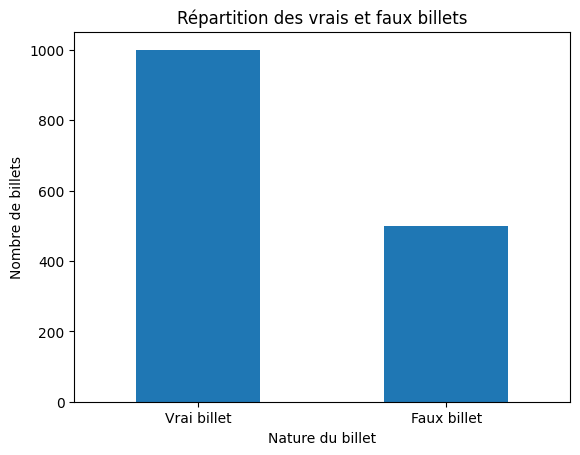

In [6]:
# Visualisation de la répartition de la variable cible

repartition_graphique = (
    df["is_genuine"]
    .map({True: "Vrai billet", False: "Faux billet"})
    .value_counts())

repartition_graphique.plot(kind="bar")

plt.title("Répartition des vrais et faux billets")
plt.xlabel("Nature du billet")
plt.ylabel("Nombre de billets")
plt.xticks(rotation=0)
plt.show()

La représentation graphique confirme que les billets authentiques sont deux fois plus nombreux que les faux billets.

Ce déséquilibre reste modéré, mais il devra être pris en compte lors de l’évaluation des modèles. L’accuracy seule ne sera donc pas suffisante pour comparer leurs performances.

In [7]:
# Statistiques descriptives des variables géométriques

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
diagonal,1500.0,171.958440,0.305195,171.04,171.750,171.96,172.17,173.01
height_left,1500.0,104.029533,0.299462,103.14,103.820,104.04,104.23,104.88
height_right,1500.0,103.920307,0.325627,102.82,103.710,103.92,104.15,104.95
margin_low,1463.0,4.485967,0.663813,2.98,4.015,4.31,4.87,6.90
margin_up,1500.0,3.151473,0.231813,2.27,2.990,3.14,3.31,3.91
length,1500.0,112.678500,0.872730,109.49,112.030,112.96,113.34,114.44


### Statistiques descriptives des variables géométriques

Les six caractéristiques sont exprimées en millimètres et présentent des ordres de grandeur différents.

La variable `margin_low` ne contient que 1 463 observations, ce qui confirme la présence des 37 valeurs manquantes précédemment identifiées.

Les moyennes et les médianes sont globalement proches pour plusieurs variables. Toutefois, l’étude des distributions et des valeurs extrêmes à l’aide de représentations graphiques reste nécessaire avant de conclure sur leur symétrie ou sur la présence éventuelle de valeurs atypiques.

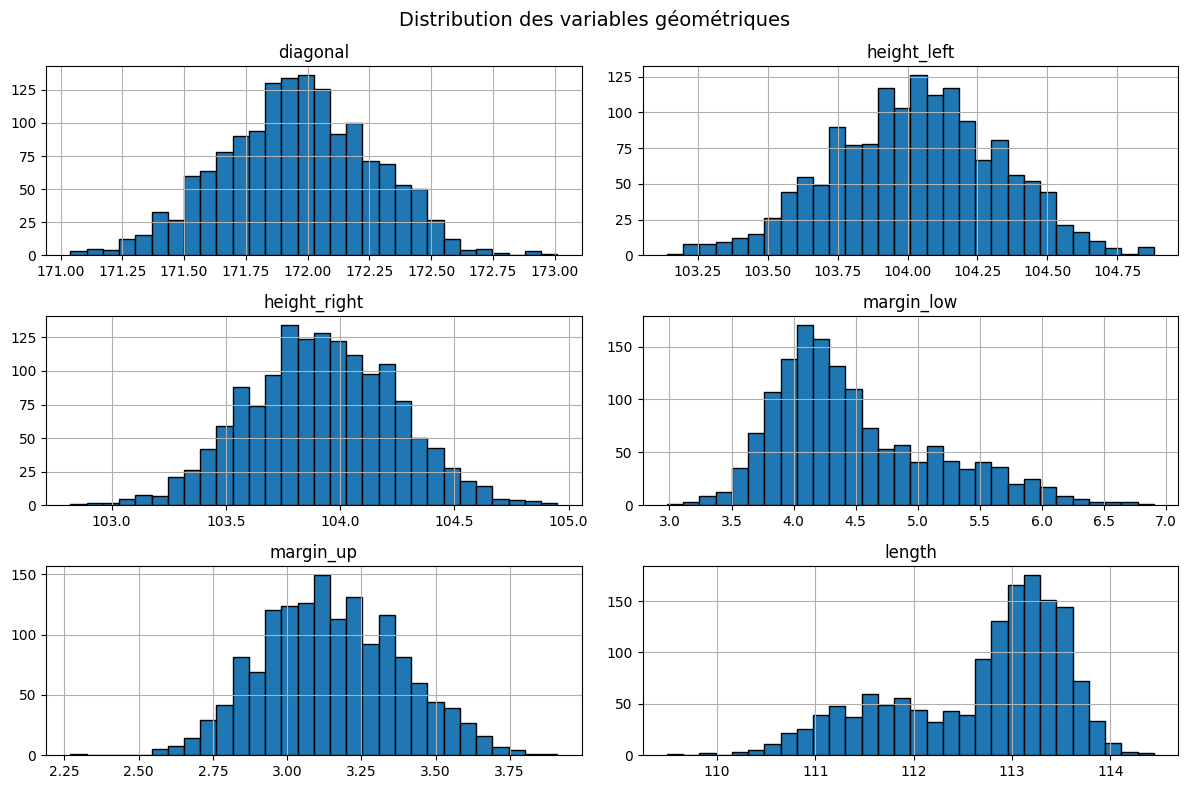

In [8]:
# Distribution des variables géométriques

variables_geometriques = [
    "diagonal",
    "height_left",
    "height_right",
    "margin_low",
    "margin_up",
    "length"]

df[variables_geometriques].hist(
    bins=30,
    figsize=(12, 8),
    edgecolor="black")

plt.suptitle(
    "Distribution des variables géométriques",
    fontsize=14)

plt.tight_layout()
plt.show()

### Analyse des distributions

Les variables `diagonal`, `height_left`, `height_right` et `margin_up` présentent des distributions globalement proches d’une forme symétrique et unimodale.

La distribution de `margin_low` est plus étalée vers les valeurs élevées et présente une asymétrie à droite.

La variable `length` semble faire apparaître deux groupes d’observations distincts. Cette structure pourrait traduire une différence entre les billets authentiques et les faux billets. Une analyse comparative selon la variable cible est donc nécessaire pour confirmer cette hypothèse.

In [9]:
# Statistiques descriptives selon la nature du billet

statistiques_par_classe = (
    df.groupby("is_genuine")[variables_geometriques].mean().T.rename(columns={
        False: "Faux billets",
        True: "Vrais billets"}))

display(statistiques_par_classe.round(3))

is_genuine,Faux billets,Vrais billets
diagonal,171.901,171.987
height_left,104.190,103.949
height_right,104.144,103.809
margin_low,5.216,4.116
margin_up,3.350,3.052
length,111.631,113.202


### Comparaison des moyennes selon la nature du billet

La comparaison des moyennes met en évidence plusieurs différences entre les billets authentiques et les faux billets.

Les billets authentiques présentent en moyenne une longueur plus élevée, tandis que les faux billets possèdent des marges inférieure et supérieure plus importantes. Les hauteurs gauche et droite sont également légèrement plus élevées pour les faux billets.

À l’inverse, la variable `diagonal` présente des moyennes très proches entre les deux catégories.

Les variables `length` et `margin_low` semblent donc particulièrement discriminantes pour distinguer les vrais billets des faux. Toutefois, l’analyse des seules moyennes ne permet pas d’évaluer la dispersion des valeurs ni le chevauchement entre les distributions des deux classes.

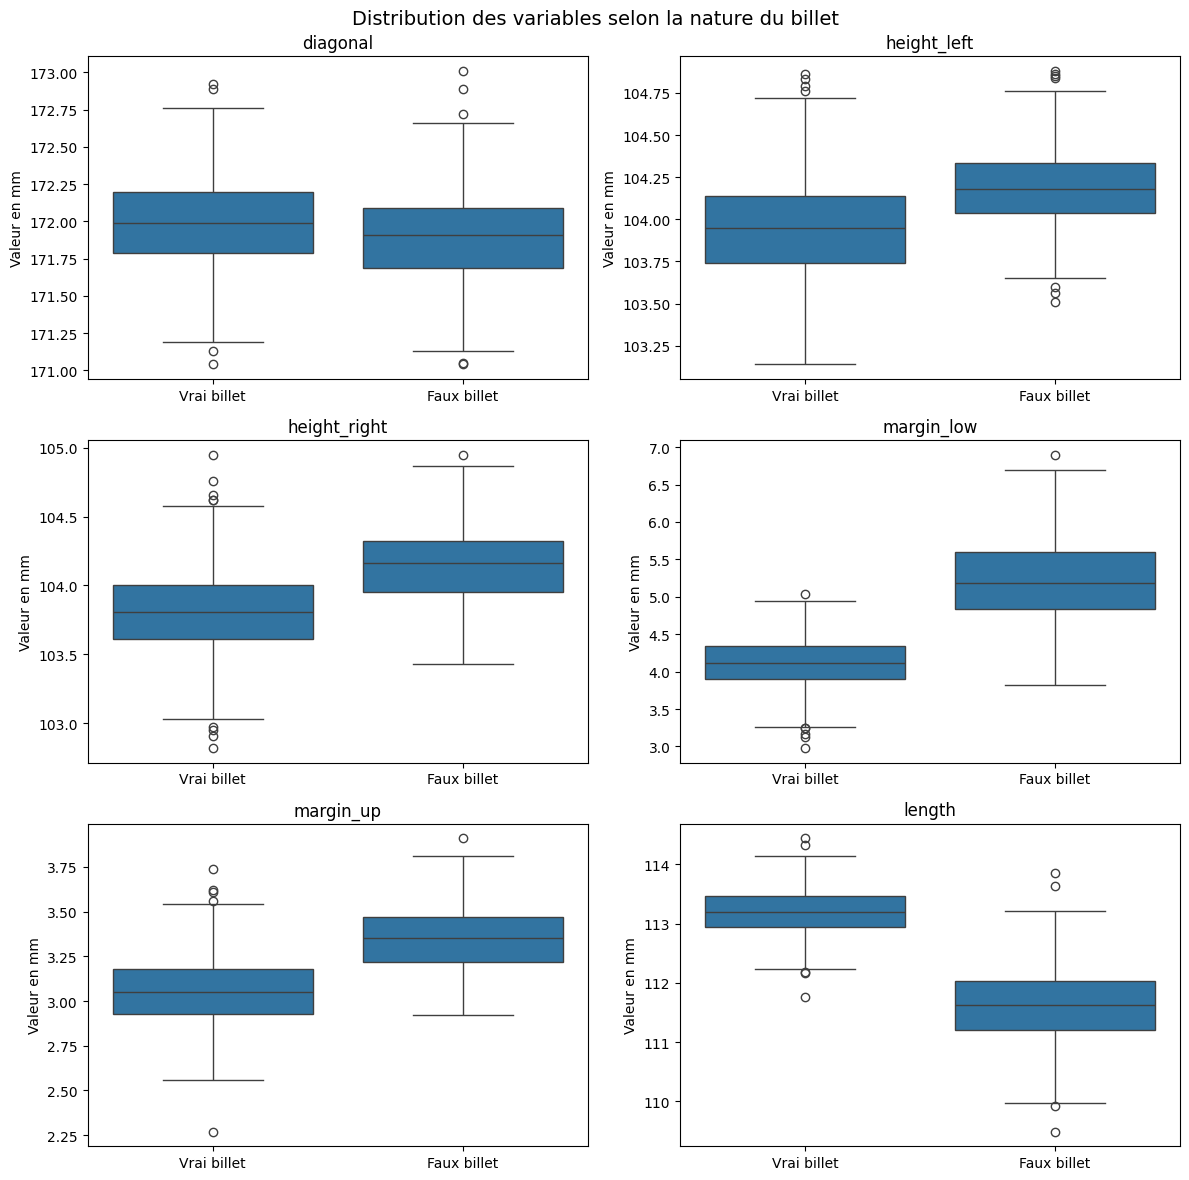

In [10]:
# Comparaison des distributions selon la nature du billet

df_boxplot = df.copy()
df_boxplot["nature_billet"] = df_boxplot["is_genuine"].map({
    True: "Vrai billet",
    False: "Faux billet"})

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for variable, ax in zip(variables_geometriques, axes.flatten()):
    sns.boxplot(
        data=df_boxplot,
        x="nature_billet",
        y=variable,
        ax=ax)
    
    ax.set_title(variable)
    ax.set_xlabel("")
    ax.set_ylabel("Valeur en mm")

plt.suptitle(
    "Distribution des variables selon la nature du billet",
    fontsize=14)

plt.tight_layout()
plt.show()

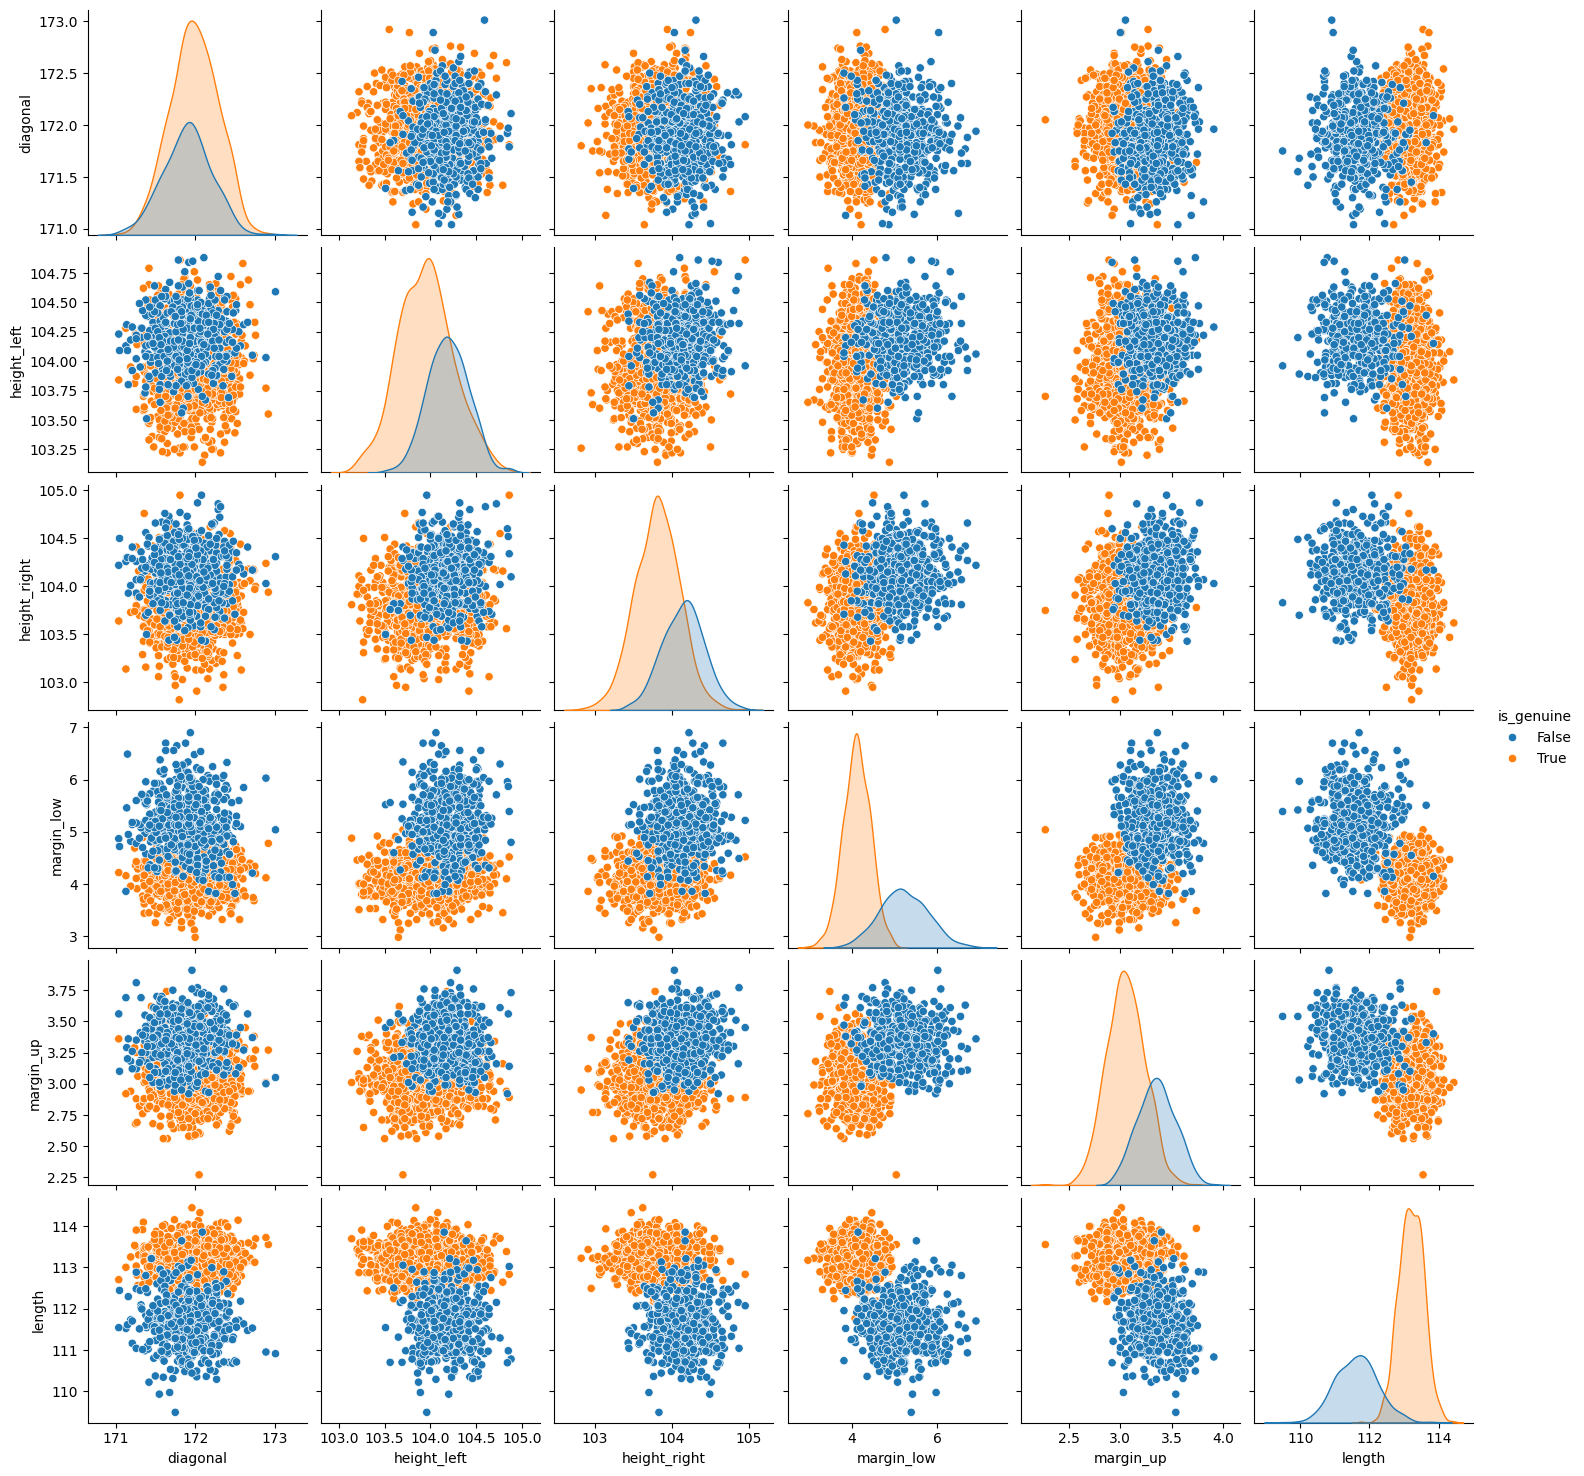

In [11]:
sns.pairplot(df,hue="is_genuine")

### Comparaison des distributions selon la nature du billet

Les boxplots confirment les différences observées précédemment entre les billets authentiques et les faux billets.

Les variables `length` et `margin_low` présentent les séparations les plus marquées entre les deux classes. Les billets authentiques sont généralement plus longs, tandis que les faux billets possèdent une marge inférieure nettement plus élevée.

Les variables `margin_up`, `height_left` et `height_right` montrent également un décalage entre les distributions, avec des valeurs généralement plus élevées pour les faux billets. Toutefois, un chevauchement entre les deux classes reste visible.

À l’inverse, la variable `diagonal` présente des distributions très proches et fortement superposées. Elle semble donc moins discriminante lorsqu’elle est considérée isolément.

Quelques valeurs atypiques sont observées pour plusieurs variables. Elles ne doivent pas être supprimées automatiquement, car elles peuvent correspondre à des billets réels présentant des mesures plus extrêmes.

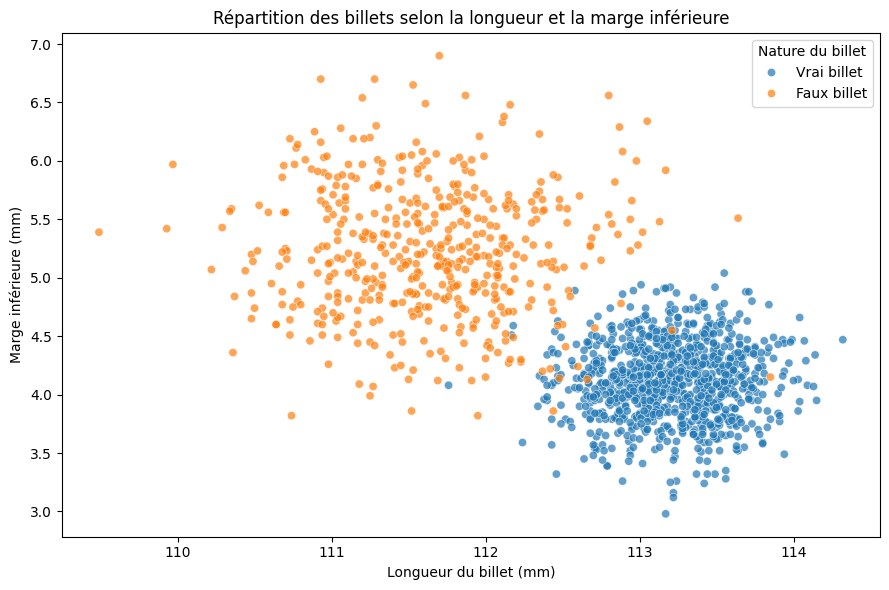

In [12]:
# Relation entre les deux variables les plus discriminantes

df_scatter = df.copy()

df_scatter["nature_billet"] = df_scatter["is_genuine"].map({
    True: "Vrai billet",
    False: "Faux billet"})

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_scatter,
    x="length",
    y="margin_low",
    hue="nature_billet",
    alpha=0.7)

plt.title(
    "Répartition des billets selon la longueur et la marge inférieure")
plt.xlabel("Longueur du billet (mm)")
plt.ylabel("Marge inférieure (mm)")
plt.legend(title="Nature du billet")
plt.tight_layout()
plt.show()

### Relation entre les deux variables les plus discriminantes

Le nuage de points confirme que la combinaison de `length` et de `margin_low` permet de distinguer visuellement une grande partie des billets authentiques et des faux billets.

Les billets authentiques sont généralement plus longs et présentent une marge inférieure plus faible. À l’inverse, les faux billets sont en moyenne plus courts et possèdent une marge inférieure plus élevée.

Une zone de chevauchement subsiste toutefois entre les deux groupes. Ces deux variables ne permettent donc pas, à elles seules, d’obtenir une séparation parfaite. L’utilisation conjointe des six caractéristiques géométriques reste nécessaire pour traiter les observations situées dans cette zone intermédiaire.

Les observations pour lesquelles `margin_low` est manquante ne sont pas représentées dans ce graphique.

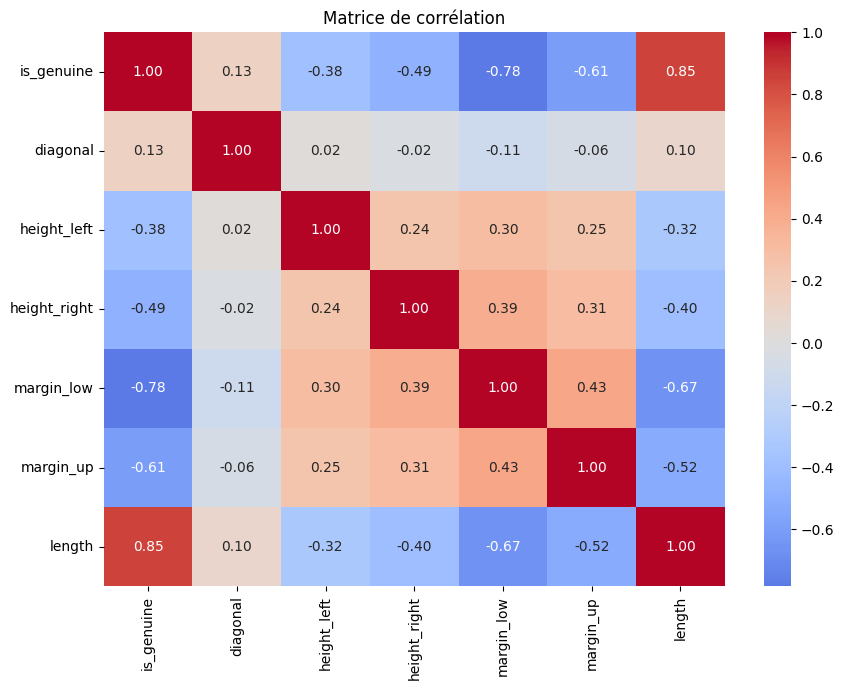

In [13]:
# Matrice de corrélation

df_correlation = df.copy()
df_correlation["is_genuine"] = df_correlation["is_genuine"].astype(int)

matrice_correlation = df_correlation.corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    matrice_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0)

plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

### Analyse des corrélations

La variable cible a été convertie en valeurs numériques, avec `0` pour les faux billets et `1` pour les billets authentiques.

La matrice de corrélation confirme que la variable `length` est fortement et positivement associée à l’authenticité du billet (`r = 0,85`). Les billets les plus longs ont donc davantage tendance à être authentiques.

À l’inverse, `margin_low` présente une forte corrélation négative avec la variable cible (`r = -0,78`) : une marge inférieure élevée est davantage associée aux faux billets.

La variable `margin_up` montre également une relation négative importante (`r = -0,61`). Les variables `height_right` et `height_left` présentent des corrélations plus modérées, tandis que `diagonal` semble peu liée à la nature du billet.

Certaines variables explicatives sont également corrélées entre elles, notamment `margin_low` et `length`. Ces relations devront être prises en compte lors de l’interprétation des modèles.

La corrélation mesure uniquement une relation linéaire et ne permet pas, à elle seule, de conclure à une relation de causalité.

In [14]:
# Répartition des valeurs manquantes de margin_low selon la nature du billet

valeurs_manquantes_par_classe = (
    df.assign(margin_low_manquante=df["margin_low"].isna())
    .groupby("is_genuine")["margin_low_manquante"]
    .agg(["sum", "count"]))

valeurs_manquantes_par_classe["proportion (%)"] = (
    valeurs_manquantes_par_classe["sum"]
    / valeurs_manquantes_par_classe["count"] * 100).round(2)

valeurs_manquantes_par_classe = valeurs_manquantes_par_classe.rename(
    index={True: "Vrais billets", False: "Faux billets"},
    columns={
        "sum": "valeurs_manquantes",
        "count": "nombre_billets"})

display(valeurs_manquantes_par_classe)

,valeurs_manquantes,nombre_billets,proportion (%)
is_genuine,,,
Faux billets,8,500,1.6
Vrais billets,29,1000,2.9


## 3. Prétraitement des données

Cette étape consiste à préparer les données avant l’entraînement des modèles.

Nous allons notamment :

- séparer les variables explicatives de la variable cible ;
- diviser les données en ensembles d’entraînement et de test ;
- traiter les valeurs manquantes ;
- standardiser les variables pour les modèles qui y sont sensibles ;
- éviter toute fuite de données grâce à l’utilisation de pipelines.

In [15]:
# Séparation des variables explicatives et de la variable cible

X = df.drop(columns="is_genuine")
y = df["is_genuine"]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (1500, 6)
Dimensions de y : (1500,)


In [16]:
# Séparation des données en ensembles d'entraînement et de test

X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE)

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test :", y_test.shape)

Dimensions de X_train : (1200, 6)
Dimensions de X_test : (300, 6)
Dimensions de y_train : (1200,)
Dimensions de y_test : (300,)


In [17]:
# Vérification de la répartition des classes après la séparation

repartition_train = y_train.value_counts(normalize=True).mul(100).round(2)
repartition_test = y_test.value_counts(normalize=True).mul(100).round(2)

repartition_apres_split = pd.DataFrame({
    "Entraînement (%)": repartition_train,
    "Test (%)": repartition_test}).rename(index={
    True: "Vrais billets",
    False: "Faux billets"})

display(repartition_apres_split)

,Entraînement (%),Test (%)
is_genuine,,
Vrais billets,66.67,66.67
Faux billets,33.33,33.33


### Séparation des données

Le jeu de données a été divisé en deux ensembles :

- 80 % des observations sont utilisées pour l’entraînement des modèles ;
- 20 % sont réservées à leur évaluation finale.

La stratification permet de conserver des proportions similaires de vrais et de faux billets dans les deux ensembles.

Le jeu de test restera séparé et ne sera utilisé ni pendant l’entraînement ni pendant l’optimisation des modèles, afin d’obtenir une estimation objective de leurs performances sur des données non vues.

Enfin, le paramètre `random_state` garantit la reproductibilité de cette séparation.

In [18]:
# Comparaison de la moyenne et de la médiane de margin_low
# sur les données d'entraînement

moyenne_margin_low = X_train["margin_low"].mean()
mediane_margin_low = X_train["margin_low"].median()

print(f"Moyenne de margin_low : {moyenne_margin_low:.3f}")
print(f"Médiane de margin_low : {mediane_margin_low:.3f}")

Moyenne de margin_low : 4.491
Médiane de margin_low : 4.320


### Traitement des valeurs manquantes

La variable `margin_low` présente une distribution asymétrique à droite. Sa moyenne sur le jeu d’entraînement est de 4,491 mm, tandis que sa médiane est de 4,320 mm.

La médiane étant moins sensible aux valeurs extrêmes, elle sera utilisée pour imputer les valeurs manquantes.

L’imputation sera intégrée aux pipelines afin que la médiane soit calculée uniquement à partir des données d’entraînement. Cette méthode permet d’éviter toute fuite d’information provenant du jeu de test.

In [19]:
# Définition de la méthode d'imputation

imputeur_mediane = SimpleImputer(strategy="median")

print("Méthode d'imputation retenue : médiane")

Méthode d'imputation retenue : médiane


### Standardisation des variables

Même si toutes les caractéristiques géométriques sont exprimées en millimètres, elles présentent des amplitudes différentes.

La standardisation est particulièrement importante pour les algorithmes fondés sur les distances, comme le KNN et le K-means. Elle est également nécessaire pour le SVM et sera appliquée à la régression logistique afin de faciliter l’entraînement et la comparaison des coefficients.

Le Random Forest ne nécessite pas de standardisation, car son fonctionnement repose sur des règles de décision et non sur le calcul de distances.

Comme l’imputation, la standardisation sera intégrée aux pipelines et ajustée uniquement sur les données d’entraînement afin d’éviter toute fuite de données.

In [20]:
# Définition de la méthode de standardisation

standardiseur = StandardScaler()

print("Méthode de standardisation retenue : StandardScaler")

Méthode de standardisation retenue : StandardScaler


### Stratégie de validation croisée

Afin d’évaluer les modèles de manière plus robuste, une validation croisée stratifiée à cinq plis sera appliquée sur le jeu d’entraînement.

À chaque itération, quatre parties seront utilisées pour entraîner le modèle et la cinquième pour le valider. La stratification permettra de conserver la proportion de vrais et de faux billets dans chaque partie.

Les observations sont mélangées avant la création des plis, tandis que le paramètre `random_state` garantit la reproductibilité de cette répartition.

Le jeu de test restera totalement séparé et ne sera utilisé qu’après la sélection des meilleures configurations.

In [21]:
# Définition de la stratégie de validation croisée

validation_croisee = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE)

print("Validation croisée retenue : 5 plis stratifiés")

Validation croisée retenue : 5 plis stratifiés


## 4. Modélisation

Quatre méthodes seront entraînées et comparées conformément au cahier des charges :

- la régression logistique ;
- le KNN ;
- le Random Forest ;
- le K-means.

Les modèles seront d’abord évalués sur le jeu d’entraînement à l’aide de la validation croisée. Le jeu de test ne sera utilisé qu’ensuite pour l’évaluation finale.

### 4.1 Régression logistique

La régression logistique est un modèle supervisé adapté à la classification binaire. Elle permet d’estimer la probabilité qu’un billet soit authentique ou faux à partir de ses caractéristiques géométriques.

In [22]:
# Création du pipeline de régression logistique

pipeline_logistique = Pipeline([
    ("imputation", SimpleImputer(strategy="median")),
    ("standardisation", StandardScaler()),
    ("modele", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000))])

print("Pipeline de régression logistique créé.")

Pipeline de régression logistique créé.


#### Évaluation par validation croisée

La régression logistique est d’abord évaluée par validation croisée sur le jeu d’entraînement.

Une attention particulière est portée au rappel des faux billets, qui mesure la proportion de faux billets correctement détectés par le modèle.

In [23]:
# Définition des métriques d'évaluation
# La classe False correspond aux faux billets

metriques = {
    "accuracy": "accuracy",
    "precision_faux": make_scorer(
        precision_score,
        pos_label=False),

    "rappel_faux": make_scorer(
        recall_score,
        pos_label=False),

    "f1_faux": make_scorer(
        f1_score,
        pos_label=False)}

# Évaluation de la régression logistique par validation croisée

resultats_cv_logistique = cross_validate(
    pipeline_logistique,
    X_train,
    y_train,
    cv=validation_croisee,
    scoring=metriques,
    n_jobs=-1)

print("Validation croisée de la régression logistique terminée.")

Validation croisée de la régression logistique terminée.


In [24]:
# Synthèse des résultats de la validation croisée

resultats_moyens_logistique = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Précision - faux billets",
        "Rappel - faux billets",
        "F1-score - faux billets"],

    "Moyenne": [
        resultats_cv_logistique["test_accuracy"].mean(),
        resultats_cv_logistique["test_precision_faux"].mean(),
        resultats_cv_logistique["test_rappel_faux"].mean(),
        resultats_cv_logistique["test_f1_faux"].mean()],

    "Écart-type": [
        resultats_cv_logistique["test_accuracy"].std(),
        resultats_cv_logistique["test_precision_faux"].std(),
        resultats_cv_logistique["test_rappel_faux"].std(),
        resultats_cv_logistique["test_f1_faux"].std()]})

display(
    resultats_moyens_logistique.style.format({
        "Moyenne": "{:.3f}",
        "Écart-type": "{:.3f}"}))

,Métrique,Moyenne,Écart-type
0,Accuracy,0.993,0.008
1,Précision - faux billets,0.995,0.006
2,Rappel - faux billets,0.982,0.017
3,F1-score - faux billets,0.989,0.012


#### Résultats de la validation croisée

La régression logistique obtient d’excellentes performances moyennes en validation croisée.

L’accuracy moyenne atteint 99,3 %. Le modèle détecte en moyenne 98,2 % des faux billets présents dans les plis de validation. De plus, lorsqu’il prédit qu’un billet est faux, cette prédiction est correcte dans 99,5 % des cas.

Le F1-score moyen des faux billets atteint 98,9 %, ce qui traduit un excellent équilibre entre la précision et le rappel pour cette classe.

Les faibles écarts-types observés indiquent que les résultats sont stables entre les différents plis de la validation croisée.

Ces résultats restent toutefois provisoires : le modèle doit encore être évalué sur le jeu de test, qui n’a été utilisé ni pendant l’entraînement ni lors de la validation croisée.

In [25]:
# Entraînement de la régression logistique
# sur l'ensemble du jeu d'entraînement

pipeline_logistique.fit(X_train, y_train)

print("Régression logistique entraînée sur le jeu d'entraînement complet.")

Régression logistique entraînée sur le jeu d'entraînement complet.


In [26]:
# Prédictions sur le jeu de test

y_pred_logistique = pipeline_logistique.predict(X_test)

print("Prédictions réalisées sur le jeu de test.")
print(f"Nombre de prédictions : {len(y_pred_logistique)}")

Prédictions réalisées sur le jeu de test.
Nombre de prédictions : 300


#### Matrice de confusion sur le jeu de test

La matrice de confusion permet de comparer les prédictions du modèle avec la nature réelle des billets.

Elle permet notamment d’identifier les faux billets incorrectement classés comme authentiques, qui constituent l’erreur la plus sensible dans le contexte de l’ONCFM.

In [27]:
# Matrice de confusion de la régression logistique

matrice_logistique = confusion_matrix(
    y_test,
    y_pred_logistique,
    labels=[False, True])

matrice_logistique_df = pd.DataFrame(
    matrice_logistique,
    index=["Faux billets réels", "Vrais billets réels"],
    columns=["Prédits faux", "Prédits vrais"])

display(matrice_logistique_df)

,Prédits faux,Prédits vrais
Faux billets réels,98,2
Vrais billets réels,1,199


#### Performances sur le jeu de test

Les prédictions réalisées sur le jeu de test sont maintenant comparées aux valeurs réelles afin de mesurer les performances finales de la régression logistique.

Une attention particulière est portée au rappel des faux billets, qui mesure la capacité du modèle à détecter les billets contrefaits.

In [28]:
# Calcul des métriques sur le jeu de test

accuracy_logistique = accuracy_score(
    y_test,
    y_pred_logistique)

precision_faux_logistique = precision_score(
    y_test,
    y_pred_logistique,
    pos_label=False)

rappel_faux_logistique = recall_score(
    y_test,
    y_pred_logistique,
    pos_label=False)

f1_faux_logistique = f1_score(
    y_test,
    y_pred_logistique,
    pos_label=False)

print(f"Accuracy : {accuracy_logistique:.3f}")
print(f"Précision - faux billets : {precision_faux_logistique:.3f}")
print(f"Rappel - faux billets : {rappel_faux_logistique:.3f}")
print(f"F1-score - faux billets : {f1_faux_logistique:.3f}")

Accuracy : 0.990
Précision - faux billets : 0.990
Rappel - faux billets : 0.980
F1-score - faux billets : 0.985


#### Interprétation des résultats

Sur le jeu de test, la régression logistique classe correctement 99 % des billets.

Parmi les 100 faux billets présents dans le jeu de test, 98 sont correctement détectés et 2 sont incorrectement classés comme authentiques. Parmi les 200 billets authentiques, un seul est classé à tort comme faux.

Le rappel des faux billets atteint 98 %, ce qui traduit une très bonne capacité de détection des contrefaçons. Ces résultats constituent une première référence pour la comparaison avec les autres algorithmes.

#### Vérification des prédictions à partir des probabilités

La régression logistique fournit une probabilité d’appartenance à chaque classe.

Les probabilités obtenues sont utilisées pour vérifier que l’application du seuil de décision de 0,5 reproduit bien les prédictions binaires du modèle.

In [29]:
# Probabilités prédites par la régression logistique

probabilites_logistiques = pipeline_logistique.predict_proba(X_test)

classes_logistiques = (
    pipeline_logistique
    .named_steps["modele"]
    .classes_)

indice_faux = list(classes_logistiques).index(False)
indice_vrai = list(classes_logistiques).index(True)

probabilite_faux = probabilites_logistiques[:, indice_faux]
probabilite_vrai = probabilites_logistiques[:, indice_vrai]

# Vérification du seuil de décision de 0,5

predictions_depuis_probabilites = probabilite_vrai >= 0.5

predictions_confirmees = np.array_equal(
    predictions_depuis_probabilites,
    y_pred_logistique)

verification_probabilites = pd.DataFrame({
    "Classe réelle": y_test.to_numpy(),
    "Prédiction": y_pred_logistique,
    "Probabilité faux": probabilite_faux,
    "Probabilité authentique": probabilite_vrai})

display(
    verification_probabilites.head(10).style.format({
        "Probabilité faux": "{:.3f}",
        "Probabilité authentique": "{:.3f}"}))

print("Prédictions confirmées par les probabilités :",predictions_confirmees)

,Classe réelle,Prédiction,Probabilité faux,Probabilité authentique
0,True,True,0.001,0.999
1,False,False,1.000,0.000
2,False,False,1.000,0.000
3,True,True,0.360,0.640
4,True,True,0.002,0.998
5,True,True,0.000,1.000
6,True,True,0.004,0.996
7,True,True,0.000,1.000
8,True,True,0.001,0.999
9,True,True,0.013,0.987


Prédictions confirmées par les probabilités : True


In [30]:
# Enregistrement des résultats de la régression logistique

resultats_modeles = [{
    "Modèle": "Régression logistique",
    "Accuracy": accuracy_logistique,
    "Précision faux": precision_faux_logistique,
    "Rappel faux": rappel_faux_logistique,
    "F1-score faux": f1_faux_logistique,
    "Faux billets non détectés": 2}]

print("Résultats de la régression logistique enregistrés.")

Résultats de la régression logistique enregistrés.


### 4.2 K plus proches voisins — KNN

Le KNN est un algorithme supervisé qui classe un nouveau billet en observant les billets les plus proches dans le jeu d’entraînement.

La classe prédite dépend du vote majoritaire parmi les `k` voisins les plus proches.

Comme cet algorithme repose sur le calcul de distances, la standardisation des variables est indispensable. Les valeurs manquantes seront également imputées par la médiane au sein du pipeline.

In [31]:
# Création du pipeline KNN

pipeline_knn = Pipeline([
    ("imputation", SimpleImputer(strategy="median")),
    ("standardisation", StandardScaler()),
    ("modele", KNeighborsClassifier())])

print("Pipeline KNN créé.")

Pipeline KNN créé.


#### Recherche du nombre optimal de voisins

Le nombre de voisins `k` influence directement les prédictions du KNN.

Plusieurs valeurs impaires seront testées par validation croisée. L’utilisation de valeurs impaires limite les risques d’égalité lors du vote entre les deux classes.

La meilleure configuration sera sélectionnée selon le F1-score des faux billets, tout en surveillant particulièrement leur rappel.

In [32]:
# Valeurs de k à tester

parametres_knn = {
    "modele__n_neighbors": [3, 5, 7, 9, 11, 13, 15]}

# Recherche du meilleur nombre de voisins

recherche_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=parametres_knn,
    scoring=metriques,
    refit="f1_faux",
    cv=validation_croisee,
    n_jobs=-1)

recherche_knn.fit(X_train, y_train)

# Affichage des résultats pour chaque valeur de k et chaque métrique

resultats_recherche_knn = pd.DataFrame(recherche_knn.cv_results_)

colonnes_metriques = [
    colonne for colonne in resultats_recherche_knn.columns
    if colonne.startswith("mean_test_")]

resultats_recherche_knn = resultats_recherche_knn[
    ["param_modele__n_neighbors"] + colonnes_metriques].copy()

resultats_recherche_knn = resultats_recherche_knn.rename(
    columns={
        "param_modele__n_neighbors": "Nombre de voisins k",
        **{
            colonne: colonne.replace("mean_test_", "")
            for colonne in colonnes_metriques}})

resultats_recherche_knn = resultats_recherche_knn.sort_values("Nombre de voisins k")

display(
    resultats_recherche_knn.style.format({
            colonne: "{:.3f}"
            for colonne in resultats_recherche_knn.columns
            if colonne != "Nombre de voisins k"}))

print("Recherche des paramètres KNN terminée.")
print("Meilleurs paramètres :", recherche_knn.best_params_)
print("Meilleur F1-score moyen des faux billets :", round(recherche_knn.best_score_, 3))


,Nombre de voisins k,accuracy,precision_faux,rappel_faux,f1_faux
0,3,0.988,0.987,0.975,0.981
1,5,0.988,0.992,0.972,0.982
2,7,0.992,0.995,0.980,0.987
3,9,0.990,0.995,0.975,0.985
4,11,0.992,0.995,0.980,0.987
5,13,0.991,0.995,0.977,0.986
6,15,0.992,0.997,0.977,0.987


Recherche des paramètres KNN terminée.
Meilleurs paramètres : {'modele__n_neighbors': 7}
Meilleur F1-score moyen des faux billets : 0.987


In [33]:
# Meilleur nombre de voisins sélectionné

meilleur_k = recherche_knn.best_params_["modele__n_neighbors"]
meilleur_f1_cv_knn = recherche_knn.best_score_

print(f"Meilleur nombre de voisins : {meilleur_k}")
print(f"Meilleur F1-score moyen des faux billets : {meilleur_f1_cv_knn:.3f}")

Meilleur nombre de voisins : 7
Meilleur F1-score moyen des faux billets : 0.987


#### Sélection du nombre de voisins

La validation croisée a sélectionné une valeur de `k = 7`.

Pour chaque nouvelle observation, le modèle prendra donc en compte les sept billets les plus proches et attribuera la classe majoritaire parmi ces voisins.

Cette configuration obtient un F1-score moyen de 0,987 pour les faux billets en validation croisée sur le jeu d’entraînement.

In [34]:
# Récupération du meilleur modèle KNN

meilleur_knn = recherche_knn.best_estimator_

# Prédictions sur le jeu de test

y_pred_knn = meilleur_knn.predict(X_test)

print("Prédictions KNN réalisées sur le jeu de test.")
print(f"Nombre de prédictions : {len(y_pred_knn)}")

Prédictions KNN réalisées sur le jeu de test.
Nombre de prédictions : 300


#### Matrice de confusion du KNN

La matrice de confusion permet d’analyser les erreurs commises par le KNN sur le jeu de test, notamment le nombre de faux billets incorrectement classés comme authentiques.

In [35]:
# Matrice de confusion du KNN

matrice_knn = confusion_matrix(
    y_test,
    y_pred_knn,
    labels=[False, True])

matrice_knn_df = pd.DataFrame(
    matrice_knn,
    index=["Faux billets réels", "Vrais billets réels"],
    columns=["Prédits faux", "Prédits vrais"])

display(matrice_knn_df)

,Prédits faux,Prédits vrais
Faux billets réels,97,3
Vrais billets réels,1,199


#### Interprétation de la matrice de confusion

Sur les 100 faux billets du jeu de test, le KNN en détecte correctement 97 et en classe 3 à tort comme authentiques.

Parmi les 200 billets authentiques, 199 sont correctement identifiés et un seul est classé comme faux.

Le KNN présente donc d’excellentes performances, mais laisse passer un faux billet de plus que la régression logistique.

In [36]:
# Calcul des métriques du KNN sur le jeu de test

accuracy_knn = accuracy_score(y_test, y_pred_knn)

precision_faux_knn = precision_score(
    y_test,
    y_pred_knn,
    pos_label=False)

rappel_faux_knn = recall_score(
    y_test,
    y_pred_knn,
    pos_label=False)

f1_faux_knn = f1_score(
    y_test,
    y_pred_knn,
    pos_label=False)

print(f"Accuracy : {accuracy_knn:.3f}")
print(f"Précision - faux billets : {precision_faux_knn:.3f}")
print(f"Rappel - faux billets : {rappel_faux_knn:.3f}")
print(f"F1-score - faux billets : {f1_faux_knn:.3f}")

Accuracy : 0.987
Précision - faux billets : 0.990
Rappel - faux billets : 0.970
F1-score - faux billets : 0.980


#### Résultats du KNN sur le jeu de test

Le KNN obtient une accuracy de 98,7 % sur le jeu de test.

Il détecte 97 % des faux billets et présente un F1-score de 98 %. Ces performances sont très élevées, mais légèrement inférieures à celles de la régression logistique.

Le KNN laisse passer trois faux billets, contre deux pour la régression logistique.

In [37]:
# Enregistrement des résultats du KNN

resultats_modeles.append({
    "Modèle": "KNN",
    "Accuracy": accuracy_knn,
    "Précision faux": precision_faux_knn,
    "Rappel faux": rappel_faux_knn,
    "F1-score faux": f1_faux_knn,
    "Faux billets non détectés": 3})

print("Résultats du KNN enregistrés.")

Résultats du KNN enregistrés.


### 4.3 Random Forest

Le Random Forest est un algorithme supervisé constitué d’un ensemble d’arbres de décision.

Chaque arbre réalise une prédiction à partir d’une partie des observations et des variables. La classe finale est déterminée par le vote majoritaire de l’ensemble des arbres.

Contrairement au KNN, le Random Forest ne repose pas sur le calcul de distances. La standardisation des variables n’est donc pas nécessaire. L’imputation des valeurs manquantes reste cependant indispensable.

In [38]:
# Création du pipeline Random Forest

pipeline_random_forest = Pipeline([
    ("imputation", SimpleImputer(strategy="median")),
    ("modele", RandomForestClassifier(
        random_state=RANDOM_STATE))])

print("Pipeline Random Forest créé.")

Pipeline Random Forest créé.


#### Optimisation des paramètres du Random Forest

Plusieurs configurations du Random Forest seront comparées par validation croisée.

La sélection portera notamment sur :

- le nombre d’arbres ;
- la profondeur maximale des arbres ;
- le nombre minimal d’observations dans les feuilles ;
- la prise en compte éventuelle du déséquilibre entre les classes.

La meilleure configuration sera sélectionnée selon le F1-score des faux billets.

In [39]:
# Paramètres à tester pour le Random Forest

parametres_random_forest = {
    "modele__n_estimators": [100, 200],
    "modele__max_depth": [None, 5, 10],
    "modele__min_samples_leaf": [1, 2, 4],
    "modele__class_weight": [None, "balanced"]}

# Recherche de la meilleure configuration

recherche_random_forest = GridSearchCV(
    estimator=pipeline_random_forest,
    param_grid=parametres_random_forest,
    scoring=metriques,
    refit="f1_faux",
    cv=validation_croisee,
    n_jobs=-1)

recherche_random_forest.fit(X_train, y_train)

print("Recherche des paramètres Random Forest terminée.")

Recherche des paramètres Random Forest terminée.


In [40]:
# Meilleurs paramètres du Random Forest

meilleurs_parametres_rf = recherche_random_forest.best_params_
meilleur_f1_cv_rf = recherche_random_forest.best_score_

print("Meilleurs paramètres :")
for parametre, valeur in meilleurs_parametres_rf.items():
    print(f"- {parametre} : {valeur}")

print(
    f"\nMeilleur F1-score moyen des faux billets : "
    f"{meilleur_f1_cv_rf:.3f}")

Meilleurs paramètres :
- modele__class_weight : None
- modele__max_depth : None
- modele__min_samples_leaf : 2
- modele__n_estimators : 100

Meilleur F1-score moyen des faux billets : 0.987


#### Sélection des paramètres du Random Forest

La validation croisée a sélectionné un Random Forest composé de 100 arbres, sans limitation prédéfinie de leur profondeur.

Un minimum de deux observations par feuille a été retenu, ce qui limite la création de règles reposant sur une seule observation.

La pondération des classes n’a pas été sélectionnée, car elle n’a pas amélioré le F1-score des faux billets. La configuration retenue obtient un F1-score moyen de 0,987 lors de la validation croisée.

In [41]:
# Récupération du meilleur modèle Random Forest

meilleur_random_forest = recherche_random_forest.best_estimator_

# Prédictions sur le jeu de test

y_pred_random_forest = meilleur_random_forest.predict(X_test)

print("Prédictions Random Forest réalisées sur le jeu de test.")
print(f"Nombre de prédictions : {len(y_pred_random_forest)}")

Prédictions Random Forest réalisées sur le jeu de test.
Nombre de prédictions : 300


#### Matrice de confusion du Random Forest

La matrice de confusion permet d’identifier le nombre de billets correctement classés ainsi que les erreurs commises par le Random Forest sur le jeu de test.

Une attention particulière est portée aux faux billets classés à tort comme authentiques.

In [42]:
# Matrice de confusion du Random Forest

matrice_random_forest = confusion_matrix(
    y_test,
    y_pred_random_forest,
    labels=[False, True])

matrice_random_forest_df = pd.DataFrame(
    matrice_random_forest,
    index=["Faux billets réels", "Vrais billets réels"],
    columns=["Prédits faux", "Prédits vrais"])

display(matrice_random_forest_df)

,Prédits faux,Prédits vrais
Faux billets réels,98,2
Vrais billets réels,1,199


#### Interprétation de la matrice de confusion

Sur les 100 faux billets du jeu de test, le Random Forest en détecte correctement 98 et en classe 2 à tort comme authentiques.

Parmi les 200 billets authentiques, 199 sont correctement identifiés et un seul est classé comme faux.

La matrice de confusion est identique à celle obtenue avec la régression logistique.

In [43]:
# Calcul des métriques du Random Forest sur le jeu de test

accuracy_random_forest = accuracy_score(
    y_test,
    y_pred_random_forest)

precision_faux_random_forest = precision_score(
    y_test,
    y_pred_random_forest,
    pos_label=False)

rappel_faux_random_forest = recall_score(
    y_test,
    y_pred_random_forest,
    pos_label=False)

f1_faux_random_forest = f1_score(
    y_test,
    y_pred_random_forest,
    pos_label=False)

print(f"Accuracy : {accuracy_random_forest:.3f}")
print(
    f"Précision - faux billets : "
    f"{precision_faux_random_forest:.3f}")
print(
    f"Rappel - faux billets : "
    f"{rappel_faux_random_forest:.3f}")
print(
    f"F1-score - faux billets : "
    f"{f1_faux_random_forest:.3f}")

Accuracy : 0.990
Précision - faux billets : 0.990
Rappel - faux billets : 0.980
F1-score - faux billets : 0.985


#### Résultats du Random Forest sur le jeu de test

Le Random Forest obtient une accuracy de 99 % sur le jeu de test.

Il détecte 98 % des faux billets et présente un F1-score de 98,5 %. Ses résultats sont identiques à ceux de la régression logistique sur cet échantillon de test.

Le choix final entre ces deux modèles ne pourra donc pas reposer uniquement sur leurs performances sur le jeu de test. D’autres critères, comme la stabilité en validation croisée, l’interprétabilité et la simplicité du modèle, devront également être pris en compte.

In [44]:
# Enregistrement des résultats du Random Forest

resultats_modeles.append({
    "Modèle": "Random Forest",
    "Accuracy": accuracy_random_forest,
    "Précision faux": precision_faux_random_forest,
    "Rappel faux": rappel_faux_random_forest,
    "F1-score faux": f1_faux_random_forest,
    "Faux billets non détectés": 2})

print("Résultats du Random Forest enregistrés.")

Résultats du Random Forest enregistrés.


### 4.4 K-means

Le K-means est un algorithme non supervisé. Contrairement aux modèles précédents, il ne connaît pas la variable cible `is_genuine` pendant l’apprentissage.

Il regroupe les billets selon la proximité de leurs caractéristiques géométriques. Deux groupes seront créés, puis chaque cluster sera associé à la classe majoritaire qu’il contient.

Comme le K-means repose sur les distances, l’imputation des valeurs manquantes et la standardisation des variables sont nécessaires.

In [45]:
# Prétraitement des données pour le K-means

pretraitement_kmeans = Pipeline([
    ("imputation", SimpleImputer(strategy="median")),
    ("standardisation", StandardScaler())])

X_train_kmeans = pretraitement_kmeans.fit_transform(X_train)
X_test_kmeans = pretraitement_kmeans.transform(X_test)

print("Données préparées pour le K-means.")
print("Dimensions du jeu d'entraînement :", X_train_kmeans.shape)
print("Dimensions du jeu de test :", X_test_kmeans.shape)

Données préparées pour le K-means.
Dimensions du jeu d'entraînement : (1200, 6)
Dimensions du jeu de test : (300, 6)


In [46]:
# Création et entraînement du modèle K-means

modele_kmeans = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE, n_init=20)

clusters_train = modele_kmeans.fit_predict(X_train_kmeans)

print("K-means entraîné sur le jeu d'entraînement.")
print("Clusters créés :", np.unique(clusters_train))

K-means entraîné sur le jeu d'entraînement.
Clusters créés : [0 1]


#### Analyse de la composition des clusters

Les numéros attribués aux clusters n’ont pas de signification particulière. Le cluster 0 ne correspond donc pas automatiquement aux faux billets, ni le cluster 1 aux billets authentiques.

La composition de chaque cluster est comparée aux classes réelles du jeu d’entraînement afin d’identifier la classe majoritaire de chaque groupe.

In [47]:
# Composition des clusters selon la nature réelle des billets

composition_clusters = pd.crosstab(
    pd.Series(clusters_train, name="Cluster"),
    pd.Series(y_train.to_numpy(), name="is_genuine")).rename(columns={
    False: "Faux billets",
    True: "Vrais billets"})

display(composition_clusters)

is_genuine,Faux billets,Vrais billets
Cluster,,
0,388,6
1,12,794


#### Association des clusters aux classes

Le cluster 0 contient très majoritairement des faux billets : il sera donc associé à la classe `False`.

Le cluster 1 contient principalement des billets authentiques : il sera associé à la classe `True`.

Les deux clusters présentent une composition très homogène, avec environ 98,5 % des observations appartenant à leur classe majoritaire.

In [48]:
# Évaluation de la qualité du clustering K-means

score_silhouette = silhouette_score(
    X_train_kmeans,
    clusters_train)

indice_rand_ajuste = adjusted_rand_score(
    y_train,
    clusters_train)

print(f"Score de silhouette : {score_silhouette:.3f}")
print(f"Indice de Rand ajusté : {indice_rand_ajuste:.3f}")

Score de silhouette : 0.344
Indice de Rand ajusté : 0.940


### Interprétation des résultats du K-means

Le score de silhouette obtenu est de **0,344**. Il indique une séparation modérée entre les deux groupes formés par le K-means. Les clusters ne sont donc pas parfaitement distincts dans l’espace des variables, ce qui s’explique par le chevauchement partiel observé entre certains vrais et faux billets.

L’indice de Rand ajusté atteint **0,940**. Cette valeur, proche de 1, montre une très forte correspondance entre les groupes identifiés automatiquement par le K-means et les classes réelles des billets.

Ainsi, même si la structure géométrique des groupes n’est pas parfaitement séparée, le K-means parvient à retrouver de manière très satisfaisante la distinction entre vrais et faux billets.

In [49]:
# Association automatique de chaque cluster à sa classe majoritaire

correspondance_clusters = (
    pd.DataFrame({
        "cluster": clusters_train,
        "is_genuine": y_train.to_numpy()})
    .groupby("cluster")["is_genuine"]
    .agg(lambda serie: bool(serie.mode().iloc[0])).to_dict())

for cluster, classe in correspondance_clusters.items():
    nature = "Vrai billet" if classe else "Faux billet"
    print(f"Cluster {cluster} → {nature}")

Cluster 0 → Faux billet
Cluster 1 → Vrai billet


In [50]:
# Prédiction des clusters sur le jeu de test

clusters_test = modele_kmeans.predict(X_test_kmeans)

# Conversion des clusters en classes True / False

y_pred_kmeans = np.array([
    correspondance_clusters[cluster]
    for cluster in clusters_test])

print("Prédictions K-means réalisées sur le jeu de test.")
print(f"Nombre de prédictions : {len(y_pred_kmeans)}")

Prédictions K-means réalisées sur le jeu de test.
Nombre de prédictions : 300


#### Matrice de confusion du K-means

La matrice de confusion permet d’évaluer la capacité du K-means à distinguer les vrais billets des faux billets après l’association des clusters à leur classe majoritaire.

In [51]:
# Matrice de confusion du K-means

matrice_kmeans = confusion_matrix(
    y_test,
    y_pred_kmeans,
    labels=[False, True])

matrice_kmeans_df = pd.DataFrame(
    matrice_kmeans,
    index=["Faux billets réels", "Vrais billets réels"],
    columns=["Prédits faux", "Prédits vrais"])

display(matrice_kmeans_df)

,Prédits faux,Prédits vrais
Faux billets réels,98,2
Vrais billets réels,2,198


In [52]:
# Calcul des métriques du K-means sur le jeu de test

accuracy_kmeans = accuracy_score(
    y_test,
    y_pred_kmeans)

precision_faux_kmeans = precision_score(
    y_test,
    y_pred_kmeans,
    pos_label=False)

rappel_faux_kmeans = recall_score(
    y_test,
    y_pred_kmeans,
    pos_label=False)

f1_faux_kmeans = f1_score(
    y_test,
    y_pred_kmeans,
    pos_label=False)

print(f"Accuracy : {accuracy_kmeans:.3f}")
print(f"Précision - faux billets : {precision_faux_kmeans:.3f}")
print(f"Rappel - faux billets : {rappel_faux_kmeans:.3f}")
print(f"F1-score - faux billets : {f1_faux_kmeans:.3f}")

Accuracy : 0.987
Précision - faux billets : 0.980
Rappel - faux billets : 0.980
F1-score - faux billets : 0.980


#### Résultats du K-means sur le jeu de test

Le K-means obtient une accuracy de 98,7 % sur le jeu de test.

Il détecte 98 % des faux billets. Sa précision et son F1-score pour cette classe atteignent également 98 %.

Ses performances sont très élevées, mais légèrement inférieures à celles de la régression logistique et du Random Forest en raison d’un nombre plus important de billets authentiques classés à tort comme faux.

In [53]:
# Enregistrement des résultats du K-means

resultats_modeles.append({
    "Modèle": "K-means",
    "Accuracy": accuracy_kmeans,
    "Précision faux": precision_faux_kmeans,
    "Rappel faux": rappel_faux_kmeans,
    "F1-score faux": f1_faux_kmeans,
    "Faux billets non détectés": matrice_kmeans[0, 1]})

print("Résultats du K-means enregistrés.")

Résultats du K-means enregistrés.


### 4.5 Support Vector Machine — SVM

En complément des quatre algorithmes demandés dans le cahier des charges, un modèle SVM est également testé.

Le SVM cherche à construire une frontière de séparation entre les vrais et les faux billets. Il peut modéliser une frontière linéaire ou plus complexe selon le noyau utilisé.

Comme ce modèle est sensible à l’échelle des variables, l’imputation des valeurs manquantes et la standardisation sont intégrées au pipeline.

In [54]:
# Création du pipeline SVM

pipeline_svm = Pipeline([
    ("imputation", SimpleImputer(strategy="median")),
    ("standardisation", StandardScaler()),
    ("modele", SVC(
        random_state=RANDOM_STATE))])

print("Pipeline SVM créé.")

Pipeline SVM créé.


#### Optimisation des paramètres du SVM

Deux types de frontières de séparation seront comparés :

- un noyau linéaire, qui construit une frontière droite entre les classes ;
- un noyau RBF, qui permet de construire une frontière plus flexible et non linéaire.

Plusieurs valeurs du paramètre `C` seront testées. Pour le noyau RBF, différentes valeurs du paramètre `gamma` seront également comparées.

La meilleure configuration sera sélectionnée selon le F1-score des faux billets.

In [55]:
# Paramètres à tester pour le SVM

parametres_svm = [
    {
        "modele__kernel": ["linear"],
        "modele__C": [0.1, 1, 10, 100]},
    {
        "modele__kernel": ["rbf"],
        "modele__C": [0.1, 1, 10, 100],
        "modele__gamma": ["scale", 0.01, 0.1, 1]}]

# Recherche de la meilleure configuration

recherche_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=parametres_svm,
    scoring=metriques,
    refit="f1_faux",
    cv=validation_croisee,
    n_jobs=-1)

recherche_svm.fit(X_train, y_train)

print("Recherche des paramètres SVM terminée.")

Recherche des paramètres SVM terminée.


In [56]:
# Meilleurs paramètres du SVM

meilleurs_parametres_svm = recherche_svm.best_params_
meilleur_f1_cv_svm = recherche_svm.best_score_

print("Meilleurs paramètres :")
for parametre, valeur in meilleurs_parametres_svm.items():
    print(f"- {parametre} : {valeur}")

print(
    f"\nMeilleur F1-score moyen des faux billets : "
    f"{meilleur_f1_cv_svm:.3f}")

Meilleurs paramètres :
- modele__C : 100
- modele__kernel : linear

Meilleur F1-score moyen des faux billets : 0.989


#### Sélection des paramètres du SVM

La validation croisée a sélectionné un SVM avec un noyau linéaire et une valeur de `C` égale à 100.

Le noyau linéaire indique qu’une frontière de séparation relativement simple suffit à bien distinguer les deux classes. La valeur élevée de `C` augmente la pénalisation des erreurs de classification.

Cette configuration obtient un F1-score moyen de 0,989 pour les faux billets lors de la validation croisée.

In [57]:
# Récupération du meilleur modèle SVM

meilleur_svm = recherche_svm.best_estimator_

# Prédictions sur le jeu de test

y_pred_svm = meilleur_svm.predict(X_test)

print("Prédictions SVM réalisées sur le jeu de test.")
print(f"Nombre de prédictions : {len(y_pred_svm)}")

Prédictions SVM réalisées sur le jeu de test.
Nombre de prédictions : 300


#### Matrice de confusion du SVM

La matrice de confusion permet d’évaluer les erreurs commises par le SVM sur le jeu de test, notamment le nombre de faux billets classés à tort comme authentiques.

In [58]:
# Matrice de confusion du SVM

matrice_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=[False, True])

matrice_svm_df = pd.DataFrame(
    matrice_svm,
    index=["Faux billets réels", "Vrais billets réels"],
    columns=["Prédits faux", "Prédits vrais"])

display(matrice_svm_df)

,Prédits faux,Prédits vrais
Faux billets réels,97,3
Vrais billets réels,1,199


#### Interprétation de la matrice de confusion

Sur les 100 faux billets du jeu de test, le SVM en détecte correctement 97 et en classe 3 à tort comme authentiques.

Parmi les 200 billets authentiques, 199 sont correctement identifiés et un seul est classé comme faux.

Le SVM présente donc d’excellentes performances, mais laisse passer un faux billet de plus que la régression logistique et le Random Forest.

In [59]:
# Calcul des métriques du SVM sur le jeu de test

accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_faux_svm = precision_score(
    y_test,
    y_pred_svm,
    pos_label=False)

rappel_faux_svm = recall_score(
    y_test,
    y_pred_svm,
    pos_label=False)

f1_faux_svm = f1_score(
    y_test,
    y_pred_svm,
    pos_label=False)

print(f"Accuracy : {accuracy_svm:.3f}")
print(f"Précision - faux billets : {precision_faux_svm:.3f}")
print(f"Rappel - faux billets : {rappel_faux_svm:.3f}")
print(f"F1-score - faux billets : {f1_faux_svm:.3f}")

Accuracy : 0.987
Précision - faux billets : 0.990
Rappel - faux billets : 0.970
F1-score - faux billets : 0.980


#### Résultats du SVM sur le jeu de test

Le SVM obtient une accuracy de 98,7 % sur le jeu de test.

Il détecte 97 % des faux billets et présente un F1-score de 98 % pour cette classe. Ses performances sont identiques à celles du KNN sur cet échantillon de test.

Bien que le SVM constitue une piste complémentaire pertinente, il laisse passer trois faux billets, contre deux pour la régression logistique et le Random Forest.

In [60]:
# Enregistrement des résultats du SVM

resultats_modeles.append({
    "Modèle": "SVM",
    "Accuracy": accuracy_svm,
    "Précision faux": precision_faux_svm,
    "Rappel faux": rappel_faux_svm,
    "F1-score faux": f1_faux_svm,
    "Faux billets non détectés": 3})

print("Résultats du SVM enregistrés.")

Résultats du SVM enregistrés.


## 5. Comparaison et sélection du meilleur modèle

Les performances des différents algorithmes sont maintenant comparées sur le jeu de test.

La sélection du modèle final reposera principalement sur :

- la capacité à détecter les faux billets ;
- le nombre de faux billets classés à tort comme authentiques ;
- le F1-score des faux billets ;
- la performance globale ;
- la stabilité, la simplicité et l’interprétabilité du modèle.

In [61]:
# Tableau comparatif des performances sur le jeu de test

comparaison_modeles = pd.DataFrame(resultats_modeles)

comparaison_modeles = comparaison_modeles.sort_values(
    by=[
        "Faux billets non détectés",
        "F1-score faux",
        "Accuracy"],
    ascending=[True, False, False]).reset_index(drop=True)

display(
    comparaison_modeles.style.format({
        "Accuracy": "{:.3f}",
        "Précision faux": "{:.3f}",
        "Rappel faux": "{:.3f}",
        "F1-score faux": "{:.3f}"}))

,Modèle,Accuracy,Précision faux,Rappel faux,F1-score faux,Faux billets non détectés
0,Régression logistique,0.990,0.990,0.980,0.985,2
1,Random Forest,0.990,0.990,0.980,0.985,2
2,K-means,0.987,0.980,0.980,0.980,2
3,KNN,0.987,0.990,0.970,0.980,3
4,SVM,0.987,0.990,0.970,0.980,3


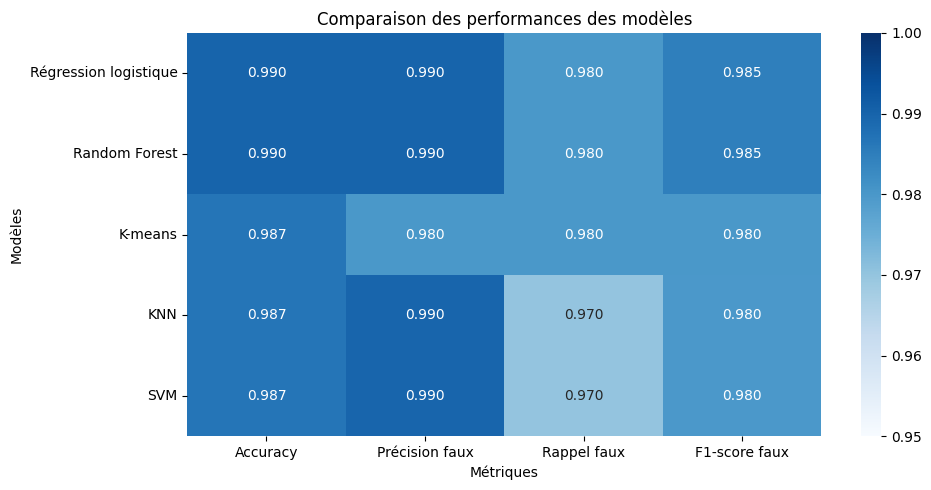

In [62]:
# Comparaison visuelle des performances des modèles

metriques_comparaison = comparaison_modeles.set_index("Modèle")[
    [
        "Accuracy",
        "Précision faux",
        "Rappel faux",
        "F1-score faux"]]

plt.figure(figsize=(10, 5))

sns.heatmap(
    metriques_comparaison,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0.95,
    vmax=1.00)

plt.title("Comparaison des performances des modèles")
plt.xlabel("Métriques")
plt.ylabel("Modèles")
plt.tight_layout()
plt.show()

### Comparaison visuelle des performances

Les cinq modèles obtiennent des performances très élevées, avec des scores compris entre 97 % et 99 %.

La régression logistique et le Random Forest présentent les meilleurs résultats globaux. Ils obtiennent tous deux une accuracy de 99 %, un rappel de 98 % et un F1-score de 98,5 % pour les faux billets.

Le K-means atteint également un rappel de 98 %, mais présente une précision légèrement inférieure. Le KNN et le SVM détectent 97 % des faux billets.

L’échelle de couleurs a été resserrée entre 0,95 et 1 afin de rendre visibles les faibles écarts entre les modèles.

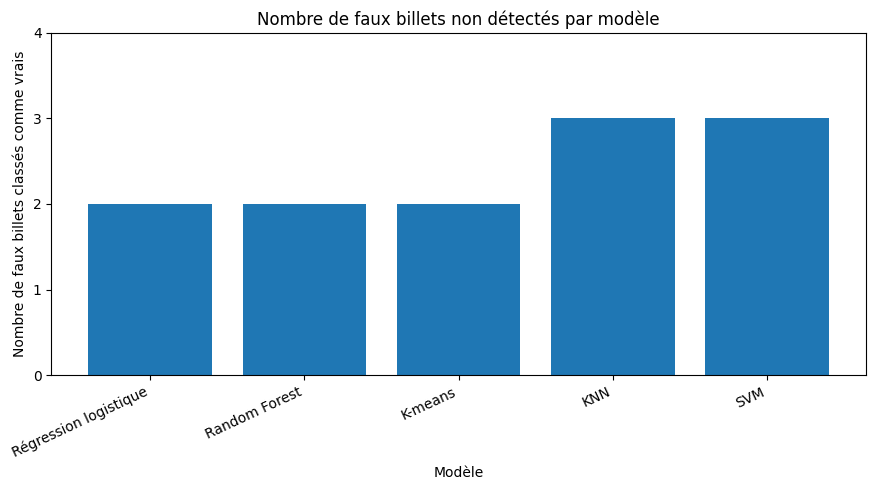

In [63]:
# Comparaison du nombre de faux billets non détectés

erreurs_faux_billets = comparaison_modeles[
    ["Modèle", "Faux billets non détectés"]].sort_values(
    by="Faux billets non détectés")

plt.figure(figsize=(9, 5))

plt.bar(
    erreurs_faux_billets["Modèle"],
    erreurs_faux_billets["Faux billets non détectés"])

plt.title("Nombre de faux billets non détectés par modèle")
plt.xlabel("Modèle")
plt.ylabel("Nombre de faux billets classés comme vrais")
plt.xticks(rotation=25, ha="right")
plt.yticks(range(0, 5))
plt.tight_layout()
plt.show()

### Analyse des faux billets non détectés

Sur les 100 faux billets présents dans le jeu de test, la régression logistique, le Random Forest et le K-means en classent deux à tort comme authentiques.

Le KNN et le SVM laissent passer trois faux billets.

Ces résultats confirment que la régression logistique, le Random Forest et le K-means obtiennent le meilleur rappel pour la classe des faux billets, avec 98 % de contrefaçons détectées.

Ce graphique porte uniquement sur les faux billets non détectés. La sélection du modèle final doit également tenir compte des autres erreurs, des performances globales et de l’interprétabilité du modèle.

### Choix du modèle final

La régression logistique et le Random Forest obtiennent les meilleures performances sur le jeu de test, avec une accuracy de 99 %, un rappel de 98 % pour les faux billets et seulement deux contrefaçons non détectées.

La régression logistique est retenue comme modèle final. Elle présente des performances comparables à celles du Random Forest, tout en étant plus simple, plus rapide et plus facilement interprétable.

Elle obtient également un F1-score moyen légèrement supérieur lors de la validation croisée. Ce choix offre donc un bon compromis entre performance, stabilité et explicabilité.

In [64]:
# Sélection du modèle final

modele_final = pipeline_logistique

print("Modèle final retenu : Régression logistique")

Modèle final retenu : Régression logistique


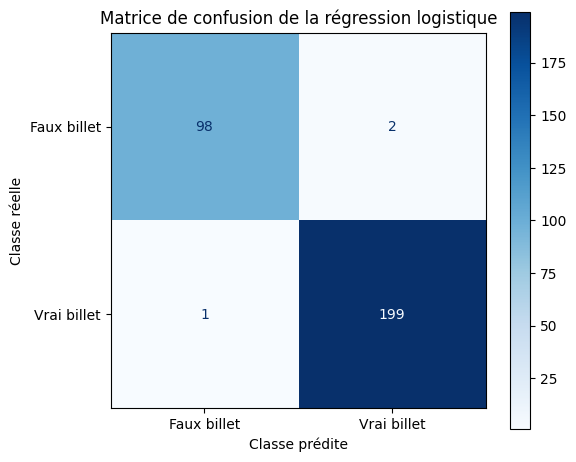

In [65]:
# Matrice de confusion graphique du modèle final

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistique,
    labels=[False, True],
    display_labels=["Faux billet", "Vrai billet"],
    cmap="Blues",
    values_format="d",
    ax=ax)

ax.set_title("Matrice de confusion de la régression logistique")
ax.set_xlabel("Classe prédite")
ax.set_ylabel("Classe réelle")

plt.tight_layout()
plt.show()

### Matrice de confusion du modèle final

La matrice de confusion confirme les excellentes performances de la régression logistique sur le jeu de test.

Parmi les 100 faux billets :

- 98 sont correctement identifiés comme faux ;
- 2 sont classés à tort comme authentiques.

Parmi les 200 billets authentiques :

- 199 sont correctement reconnus ;
- 1 est classé à tort comme faux.

Le modèle classe donc correctement 297 billets sur 300, soit une accuracy de 99 %. Il détecte 98 % des contrefaçons présentes dans le jeu de test.

Dans le contexte de l’ONCFM, l’erreur la plus sensible correspond aux deux faux billets classés comme authentiques, car ils pourraient ne pas être interceptés par le dispositif de contrôle.

### Interprétation des variables du modèle final

Les coefficients de la régression logistique permettent d’identifier le sens et l’importance de l’influence de chaque caractéristique géométrique.

La classe `True` correspondant aux billets authentiques :

- un coefficient positif augmente la probabilité qu’un billet soit authentique ;
- un coefficient négatif augmente la probabilité qu’un billet soit faux.

Plus la valeur absolue du coefficient est élevée, plus la variable contribue à la décision du modèle.

In [66]:
# Extraction des coefficients de la régression logistique

coefficients_logistiques = (
    modele_final
    .named_steps["modele"]
    .coef_[0])

importance_variables = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": coefficients_logistiques,
    "Importance absolue": np.abs(coefficients_logistiques)}).sort_values(
    by="Importance absolue",
    ascending=False
).reset_index(drop=True)

display(
    importance_variables.style.format({
        "Coefficient": "{:.3f}",
        "Importance absolue": "{:.3f}"}))

,Variable,Coefficient,Importance absolue
0,length,3.739,3.739
1,margin_low,-2.684,2.684
2,margin_up,-1.632,1.632
3,height_right,-0.709,0.709
4,height_left,-0.311,0.311
5,diagonal,0.203,0.203


#### Interprétation des coefficients

La longueur du billet est la variable qui contribue le plus à la décision du modèle. Son coefficient positif indique qu’une longueur plus élevée augmente la probabilité qu’un billet soit authentique.

À l’inverse, `margin_low` et `margin_up` présentent des coefficients négatifs importants. Des marges plus élevées sont donc davantage associées aux faux billets.

Les hauteurs gauche et droite contribuent également à la classification, mais de manière plus modérée. La diagonale présente le coefficient le plus faible et joue donc un rôle limité dans la décision du modèle.

Ces résultats confirment les observations réalisées lors de l’analyse exploratoire. Les coefficients décrivent toutefois des associations statistiques et ne doivent pas être interprétés comme des relations causales.

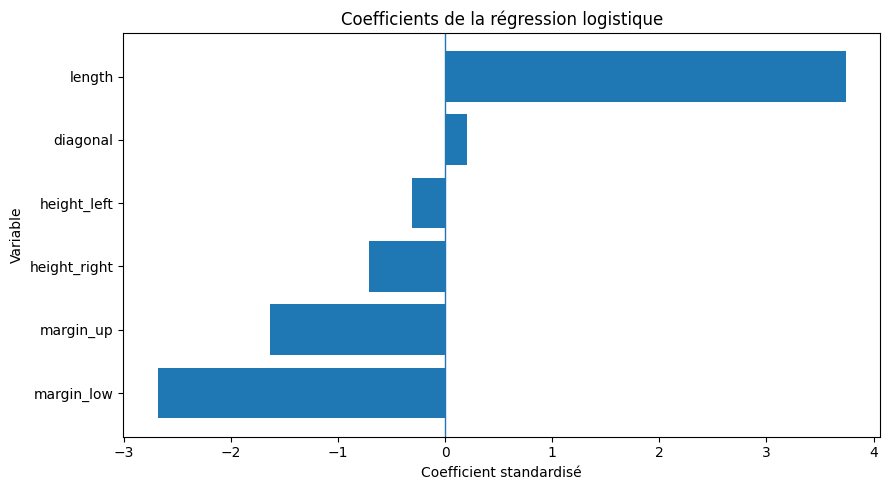

In [67]:
# Visualisation des coefficients du modèle final

importance_variables_triees = importance_variables.sort_values(
    by="Coefficient")

plt.figure(figsize=(9, 5))

plt.barh(
    importance_variables_triees["Variable"],
    importance_variables_triees["Coefficient"])

plt.axvline(0, linewidth=1)
plt.title("Coefficients de la régression logistique")
plt.xlabel("Coefficient standardisé")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 6. Sauvegarde et vérification du modèle final

Après la comparaison des différents algorithmes, la régression logistique a été retenue comme modèle final.

Le jeu de test ayant déjà permis d’évaluer objectivement ses performances, le modèle destiné à la production peut désormais être entraîné sur l’ensemble des 1 500 billets disponibles. Cette étape permet d’exploiter toutes les données connues avant son utilisation sur de nouveaux billets.

In [68]:
# Entraînement du modèle final de production
# sur l'ensemble des données disponibles

modele_final_production = Pipeline([
    ("imputation", SimpleImputer(strategy="median")),
    ("standardisation", StandardScaler()),
    ("modele", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000))])

modele_final_production.fit(X, y)

print(
    "Modèle final de production entraîné "
    "sur les 1 500 billets.")

Modèle final de production entraîné sur les 1 500 billets.


### Sauvegarde du modèle

Le pipeline complet est sauvegardé afin de pouvoir être utilisé directement par le script de prédiction.

Le fichier enregistré contient à la fois :

- la méthode d’imputation par la médiane ;
- la standardisation des variables ;
- le modèle de régression logistique entraîné.

Il ne sera donc pas nécessaire de répéter manuellement ces traitements lors de l’utilisation sur de nouveaux billets.

In [69]:
# Création du dossier destiné au modèle

DOSSIER_MODELE = Path("models")
DOSSIER_MODELE.mkdir(exist_ok=True)

CHEMIN_MODELE = DOSSIER_MODELE / "modele_detection_billets.joblib"

# Sauvegarde du pipeline complet

dump(modele_final_production, CHEMIN_MODELE)

print(f"Modèle sauvegardé dans : {CHEMIN_MODELE}")

Modèle sauvegardé dans : models\modele_detection_billets.joblib


### Vérification du modèle sauvegardé

Le modèle sauvegardé est rechargé afin de vérifier que le fichier est fonctionnel et qu’il peut être utilisé indépendamment du notebook.

Les prédictions du modèle rechargé seront comparées à celles du modèle présent en mémoire.

In [70]:
# Rechargement du modèle sauvegardé

modele_recharge = load(CHEMIN_MODELE)

# Vérification des prédictions

predictions_originales = modele_final_production.predict(X)
predictions_rechargees = modele_recharge.predict(X)

predictions_identiques = np.array_equal(
    predictions_originales,
    predictions_rechargees)

print(f"Modèle rechargé depuis : {CHEMIN_MODELE}")
print(f"Prédictions identiques : {predictions_identiques}")

Modèle rechargé depuis : models\modele_detection_billets.joblib
Prédictions identiques : True


### Test sur un fichier de production

Le modèle sauvegardé est testé sur le fichier d’exemple fourni par l’ONCFM.

Ce fichier contient les six caractéristiques géométriques ainsi qu’un identifiant, mais ne contient pas la nature réelle des billets. La colonne `id` sera conservée pour présenter les résultats, mais ne sera pas utilisée par le modèle.

In [71]:
# Chargement du fichier de production

CHEMIN_PRODUCTION = Path("billets_production.csv")

billets_production = pd.read_csv(
    CHEMIN_PRODUCTION,
    sep=None,
    engine="python")

print(f"Fichier chargé : {CHEMIN_PRODUCTION}")
print("Dimensions :", billets_production.shape)

display(billets_production)

Fichier chargé : billets_production.csv
Dimensions : (5, 7)


,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5


### Prédiction des billets du fichier de production

La colonne `id` est conservée uniquement pour identifier les billets dans le résultat. Elle n’est pas utilisée par le modèle.

Les six variables géométriques sont sélectionnées dans le même ordre que lors de l’entraînement, puis transmises au modèle sauvegardé afin d’obtenir une prédiction binaire pour chaque billet.

In [72]:
# Sélection des variables utilisées par le modèle

variables_modele = list(modele_recharge.feature_names_in_)

X_production = billets_production[variables_modele]

# Prédictions binaires

predictions_production = modele_recharge.predict(X_production)

# Tableau des résultats

resultats_production = pd.DataFrame({
    "id": billets_production["id"],
    "is_genuine": predictions_production})

display(resultats_production)

,id,is_genuine
0,A_1,False
1,A_2,False
2,A_3,False
3,A_4,True
4,A_5,True


#### Résultats sur le fichier de production

Le modèle final prédit que les billets `A_1`, `A_2` et `A_3` sont faux, tandis que les billets `A_4` et `A_5` sont authentiques.

Le fichier de production ne contenant pas les classes réelles, ces résultats constituent des prédictions et ne permettent pas de calculer des métriques de performance.

## 7. Conclusion

Cette étude a permis de construire et de comparer plusieurs méthodes de détection automatique des faux billets à partir de six caractéristiques géométriques.

Les quatre algorithmes demandés dans le cahier des charges ont été évalués : la régression logistique, le KNN, le Random Forest et le K-means. Un SVM a également été testé comme méthode complémentaire.

La régression logistique et le Random Forest obtiennent les meilleures performances sur le jeu de test, avec une accuracy de 99 % et un rappel de 98 % pour les faux billets. La régression logistique a finalement été retenue en raison de sa simplicité, de sa stabilité et de sa meilleure interprétabilité.

L’analyse de ses coefficients montre que la longueur du billet ainsi que les marges inférieure et supérieure sont les caractéristiques les plus déterminantes pour la classification.

Le pipeline final, comprenant l’imputation des valeurs manquantes, la standardisation et le modèle de classification, a été entraîné sur l’ensemble des données puis sauvegardé.

Un script indépendant, `prediction_billets.py`, permet désormais de réaliser une prédiction binaire à partir :

- d’un fichier CSV contenant plusieurs billets ;
- des six caractéristiques géométriques d’un billet unique.

L’application a été testée avec succès sur le fichier d’exemple fourni par l’ONCFM.